The purpose of this notebook is to explore the variability of different averages of OH. Need to calculate the deseasonalized mean and anomalies of OH averaged by:
1. free trop (850 to 300 hPa) vs full trop column (1000 to 350 hPa) OH
2. tropical (-23 to 23) vs global OH vs. hemispheric OH

Easiest way is probably to make an xarray DataArray with the dimensions:
- time (3000 to 6000 years)
- column ('free_trop' or 'full_trop')
- region ('tropical', 'global', 'NH', or 'SH')

This notebook will only work on the hermes cluster. The end goal is to save this xarray DataArray.

In [1]:
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from methane_noise_forcing.plotting.constants import colors_vibrant
from astropy.timeseries import LombScargle

In [2]:
## read data

# paths to deseasonalized monthly resolution data
path_free_trop = "/home/disk/hermes3/emei/LIM_experiments/GFDL_offline_2025-05-06_v0/trop_average/deseasonalized"
path_full_trop = "/home/disk/hermes3/emei/LIM_experiments/GFDL_offline_2025-08-29_v0/trop_average/deseasonalized"

# read in the data
def collect_file_names(path_to_files):
    file_list = []
    for file in path_to_files.glob("*.OH.nc"):
        # extract start year from filenames like '3001-3100.OH.nc'
        year_str = file.name.split(".")[0].split("-")[0]
        year = int(year_str)
        file_list.append((year, file))
    file_list.sort(key=lambda x: x[0])
    ordered_paths = [str(f[1]) for f in file_list]
    return ordered_paths
ds_free_trop = xr.open_mfdataset(collect_file_names(Path(path_free_trop)), combine='by_coords')
ds_full_trop = xr.open_mfdataset(collect_file_names(Path(path_full_trop)), combine='by_coords')

/tmp/ipykernel_3190949/1676143686.py:18: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds_free_trop = xr.open_mfdataset(collect_file_names(Path(path_free_trop)), combine='by_coords')
/tmp/ipykernel_3190949/1676143686.py:18: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds_free_trop = xr.open_mfdataset(collect_file_names(Path(path_free_trop)), combine='by_coords')
/tmp/ipykernel_3190949/1676143686.py:18: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range

In [3]:
## process DataSets into one dataarray with dimensions 'time' and 'column'
# add column dimension to datasets
ds_free_trop = ds_free_trop.expand_dims(column=['free_trop'])
ds_full_trop = ds_full_trop.expand_dims(column=['full_trop'])

ds_data = xr.concat([ds_free_trop, ds_full_trop], dim='column')

# change time axis to float years
time = ds_data["time"].dt.year + (ds_data["time"].dt.month - 0.5) / 12
ds_data = ds_data.assign_coords(time=time)

In [4]:
## calculate regional averages
weights = np.cos(np.deg2rad(ds_data["lat"]))
ds_data_weighted = weights * ds_data

# tropical
ds_data_weighted_tropical = ds_data_weighted.sel(lat=slice(-23, 23)).mean(dim=["lat", "lon"])
ds_data_weighted_tropical = ds_data_weighted_tropical.expand_dims(region=["tropical"])

# global
ds_data_weighted_global = ds_data_weighted.mean(dim=["lat", "lon"])
ds_data_weighted_global = ds_data_weighted_global.expand_dims(region=["global"])

# NH
ds_data_weighted_NH = ds_data_weighted.sel(lat=slice(0, 90)).mean(dim=["lat", "lon"])
ds_data_weighted_NH = ds_data_weighted_NH.expand_dims(region=["nh"])

# SH
ds_data_weighted_SH = ds_data_weighted.sel(lat=slice(-90, 0)).mean(dim=["lat", "lon"])
ds_data_weighted_SH = ds_data_weighted_SH.expand_dims(region=["sh"])

## combine data
ds_data_averaged = xr.concat([
    ds_data_weighted_tropical, 
    ds_data_weighted_global, 
    ds_data_weighted_NH, 
    ds_data_weighted_SH], dim="region")
ds_data_averaged = ds_data_averaged.compute()

In [5]:
## save
# add units
ds_data_averaged["OH"].attrs["units"] = "v/v"
# add pressure bounds
ds_data_averaged.attrs["free_trop_pressure_bounds"] = "800-300 hPa"
ds_data_averaged.attrs["full_trop_pressure_bounds"] = "1100-300 hPa"
# add bounds of tropical lat
ds_data_averaged.attrs["tropical_lat_bounds"] = "-23 to 23"
# add paths
ds_data_averaged.attrs["free_trop_path"] = path_free_trop
ds_data_averaged.attrs["full_trop_path"] = path_full_trop

# save
path_out = Path("/home/disk/p/emei/repos/methane_noise_forcing/data/oh_forcing")
ds_data_averaged.to_netcdf(path_out / "oh_forcing.nc")

# do some analysis
what does the mean and variability look like?

In [6]:
colors = {
    "tropical": colors_vibrant["blue"],
    "global": colors_vibrant["orange"],
    "nh": colors_vibrant["teal"],
    "sh": colors_vibrant["red"]
}

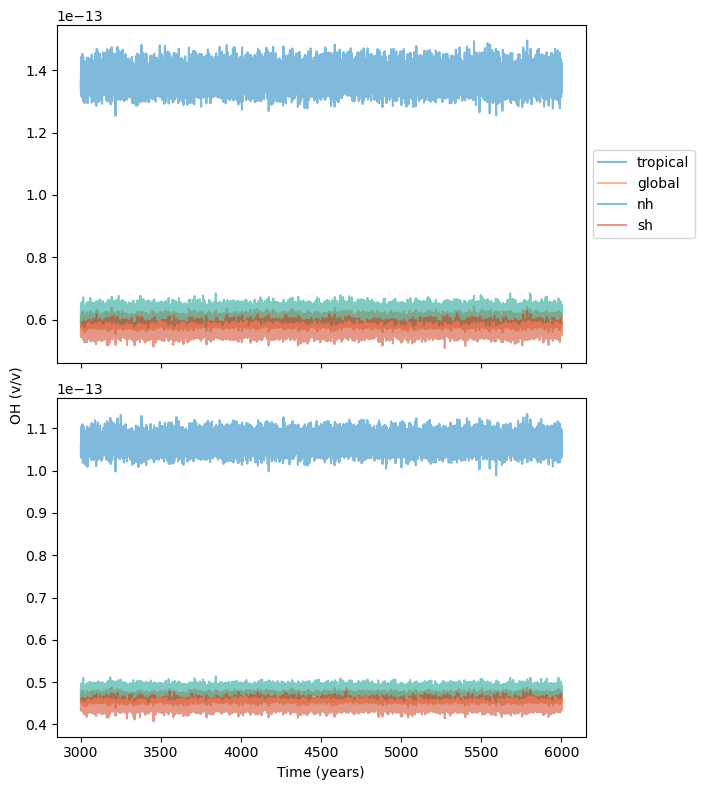

In [7]:
## first, take a peek at the raw data plotted all against each other
fig, axs = plt.subplots(2, 1, figsize=(7, 8), sharex=True)
regions_to_plot = ['tropical', 'global', 'nh', 'sh']
# regions_to_plot = ['nh', 'sh']

## upper plot is free trop
for region in regions_to_plot:
    axs[0].plot(
        ds_data_averaged.time, 
        ds_data_averaged["OH"].sel(region=region, column='free_trop'),
        color=colors[region],
        alpha=0.5,
        label=region)

## lower plot is full trop
for region in regions_to_plot:
    axs[1].plot(
        ds_data_averaged.time, 
        ds_data_averaged["OH"].sel(region=region, column='full_trop'),
        color=colors[region],
        alpha=0.5,
        label=region)

# put legend on outside right, center
axs[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))

# add labels
fig.text(0.0, 0.5, "OH (v/v)", va="center", rotation="vertical")
axs[1].set_xlabel("Time (years)")
plt.tight_layout()

In [8]:
## calculate mean, anomalies, and fraction anomalies
ds_mean = ds_data_averaged.mean(dim='time')
ds_anomalies = ds_data_averaged - ds_mean
ds_anomalies_frc = ds_anomalies / ds_mean

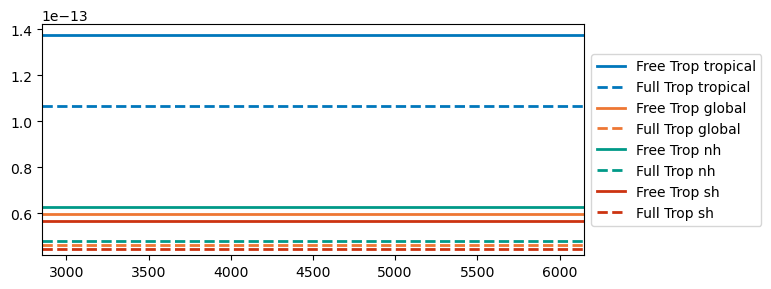

In [9]:
## plot mean on one figure
fig, ax = plt.subplots(figsize=(7, 3))
regions_to_plot = ['tropical', 'global', 'nh', 'sh']

ax.plot(ds_data_averaged.time, ds_data_averaged["OH"].sel(region=region, column='free_trop'), lw=0)

for region in regions_to_plot:
    # free trop in solid line
    ax.axhline(ds_mean["OH"].sel(region=region, column='free_trop').values.item(), color=colors[region], lw=2, label=f'Free Trop {region}')
    # full trop in dashed line
    ax.axhline(ds_mean["OH"].sel(region=region, column='full_trop'), color=colors[region], lw=2, ls='--', label=f'Full Trop {region}')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

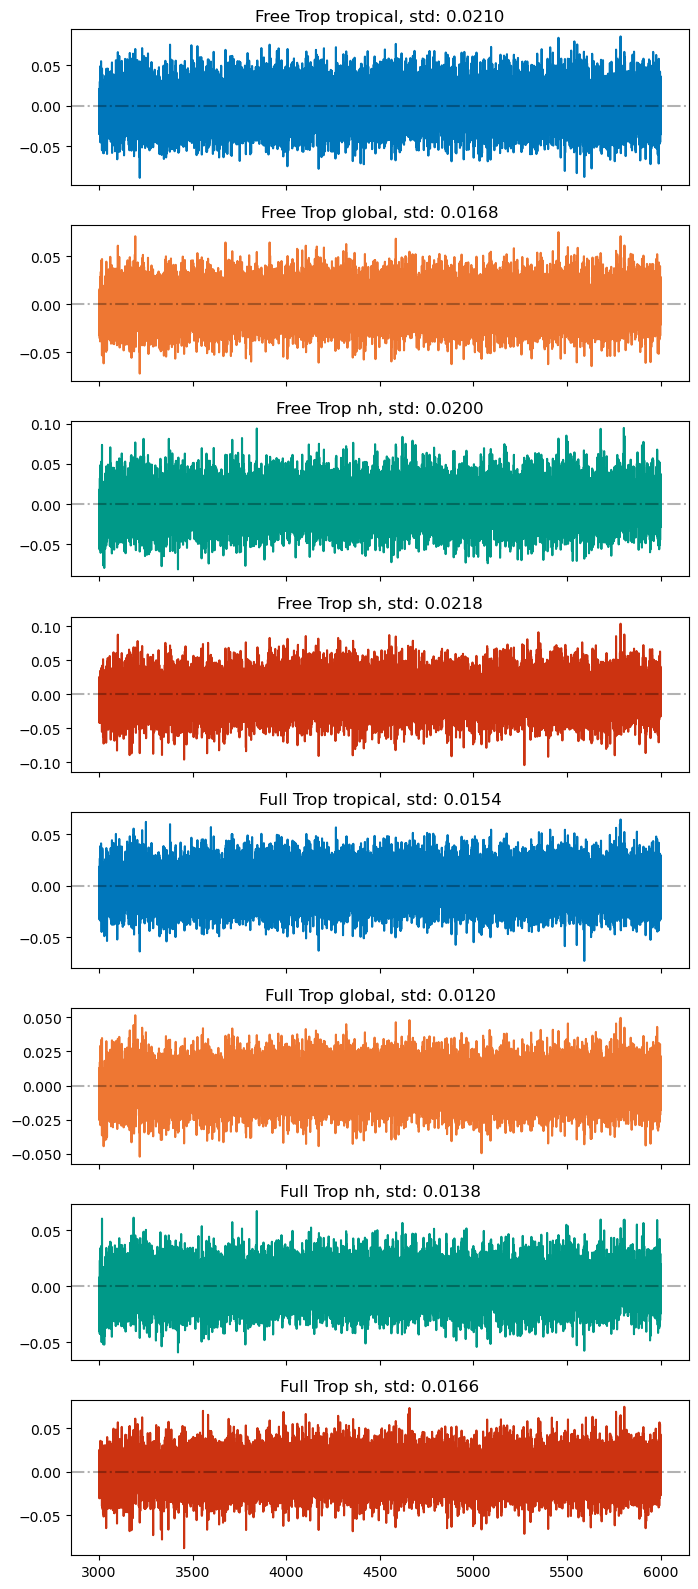

In [10]:
# plot fraction of anomalies
fig, axs = plt.subplots(8, 1, figsize=(7, 16), sharex=True)
regions_to_plot = ['tropical', 'global', 'nh', 'sh']
axs = axs.reshape(-1)

# first 4, plot free trop fractional anomalies
for i, region in enumerate(regions_to_plot):
    axs[i].plot(
        ds_anomalies_frc['time'], 
        ds_anomalies_frc['OH'].sel(region=region, column='free_trop'), 
        color=colors[region])
    axs[i].axhline(0, ls='-.', color='k', alpha=0.3)
    st_dev = ds_anomalies_frc['OH'].sel(region=region, column='free_trop').std(dim='time', ddof=1)
    axs[i].set_title(f"Free Trop {region}, std: {st_dev:.4f}")

# second 4, plot full trop fractional anomalies
for i, region in enumerate(regions_to_plot):
    axs[i + 4].plot(
        ds_anomalies_frc['time'], 
        ds_anomalies_frc['OH'].sel(region=region, column='full_trop'), 
        color=colors[region])
    axs[i + 4].axhline(0, ls='-.', color='k', alpha=0.3)
    st_dev = ds_anomalies_frc['OH'].sel(region=region, column='full_trop').std(dim='time', ddof=1)
    axs[i + 4].set_title(f"Full Trop {region}, std: {st_dev:.4f}")

plt.tight_layout()

In [11]:
# plot power spectra
psd_free_trop = []
psd_full_trop = []
for region in ['tropical', 'global', 'nh', 'sh']:
    frequencies, power_spectrum = LombScargle(
        ds_anomalies.time.values, 
        ds_anomalies["OH"].sel(region=region, column='free_trop').values
        ).autopower(
            samples_per_peak=1,
    ) # default normalization
    psd_free_trop.append(power_spectrum)

    _, power_spectrum = LombScargle(
        ds_anomalies.time.values, 
        ds_anomalies["OH"].sel(region=region, column='full_trop').values
        ).autopower(
            samples_per_peak=1,
    ) # default normalization
    psd_full_trop.append(power_spectrum)

# combine into dataarray
da_psd = xr.DataArray(
    np.array([psd_free_trop, psd_full_trop]),
    dims=["column", "region", "frequency"],
    coords={
        "column": ["free_trop", "full_trop"],
        "region": ["tropical", "global", "nh", "sh"],
        "frequency": frequencies
    }
)

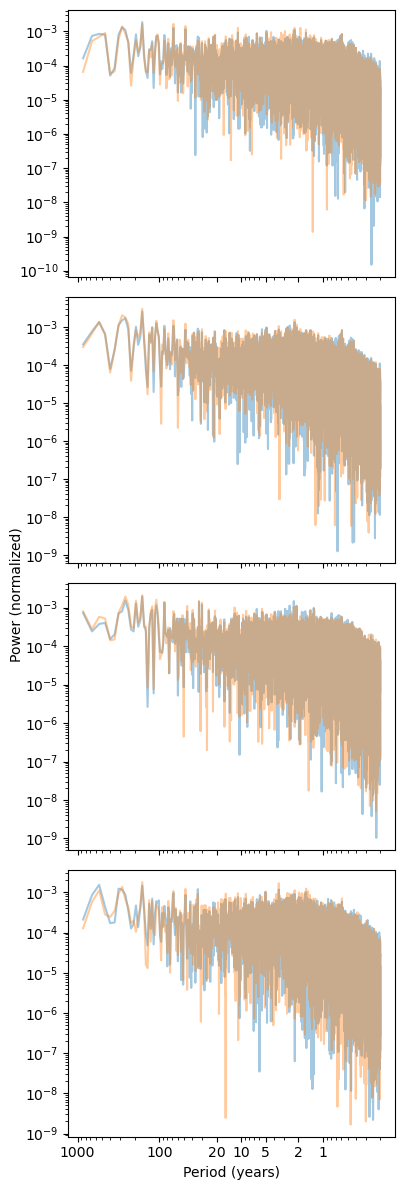

In [12]:
## plot PSDs of all regions against each other
fig, axs = plt.subplots(4, 1, figsize=(4, 12), sharex=True)
regions_to_plot = ['tropical', 'global', 'nh', 'sh']
tick_labels = [1000, 100, 20, 10, 5, 2, 1]
period_high = 1000
period_low = 0.2
mask = (frequencies >= 1/period_high) & (frequencies <= 1/period_low)
frequencies_to_plot = frequencies[mask]

for i, region in enumerate(regions_to_plot):
    axs[i].plot(
        1 / frequencies_to_plot,
        da_psd.sel(frequency=frequencies_to_plot, column='free_trop', region=region),
        color='tab:blue',
        alpha=0.4,
        label=region)

    axs[i].plot(
        1 / frequencies_to_plot,
        da_psd.sel(frequency=frequencies_to_plot, column='full_trop', region=region),
        color='tab:orange',
        alpha=0.4,
        label=region)

for ax in axs:
    ax.set_xscale('log')
    ax.set_yscale('log')
axs[-1].invert_xaxis()
axs[-1].set_xticks(tick_labels)
axs[-1].set_xticklabels([f"{tick}" for tick in tick_labels])
fig.text(0.0, 0.5, "Power (normalized)", va="center", rotation="vertical")
axs[-1].set_xlabel("Period (years)")
plt.tight_layout()